
# EDA


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, precision_score, recall_score, classification_report, PrecisionRecallDisplay, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [ ]:
file_link = 'https://drive.google.com/file/d/1VlgCO1AlSfjTku3gLdTlBJ-Lk97hMSX5/view?usp=drive_link'

# get the id part of the file
id = file_link.split("/")[-2]

# creating a new link using the id for better readability of csv file in pandas
new_link = f'https://drive.google.com/uc?id={id}'
df = pd.read_csv(new_link)
# let's look at the first few instances
df.head()

,Location,Size_sqft,Num_Bedrooms,Num_Bathrooms,Has_Balcony,Floor_Number,Building_Age_Years,Parking_Available,Nearby_Schools,Distance_to_CityCenter_km,Security_Level,Price_Category
0,Countryside,1730.0,4.0,3.0,No,3.0,24.0,No,Few,19.2,Low,High
1,City Center,2092.0,1.0,2.0,No,16.0,36.0,No,Many,2.6,Low,High
2,Countryside,NaN,3.0,1.0,Yes,8.0,47.0,No,Many,NaN,Medium,Medium
3,NaN,1945.0,3.0,2.0,Yes,18.0,42.0,Yes,Few,28.8,Low,High
4,City Center,1505.0,4.0,3.0,No,4.0,37.0,No,Many,2.8,Low,High


In [ ]:
df.shape

(1200, 12)

In [ ]:
df.isnull().sum()

,0
Location,140
Size_sqft,106
Num_Bedrooms,136
Num_Bathrooms,143
Has_Balcony,121
Floor_Number,132
Building_Age_Years,127
Parking_Available,101
Nearby_Schools,124
Distance_to_CityCenter_km,103


In [ ]:
cat_cols=df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
['Location', 'Has_Balcony', 'Parking_Available', 'Nearby_Schools', 'Security_Level', 'Price_Category']
Numerical Variables:
['Size_sqft', 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Number', 'Building_Age_Years', 'Distance_to_CityCenter_km']


Z-Score Outliers per Column:
                            Num_Outliers
Size_sqft                             0
Num_Bedrooms                          0
Num_Bathrooms                         0
Floor_Number                          0
Building_Age_Years                    0
Distance_to_CityCenter_km             0


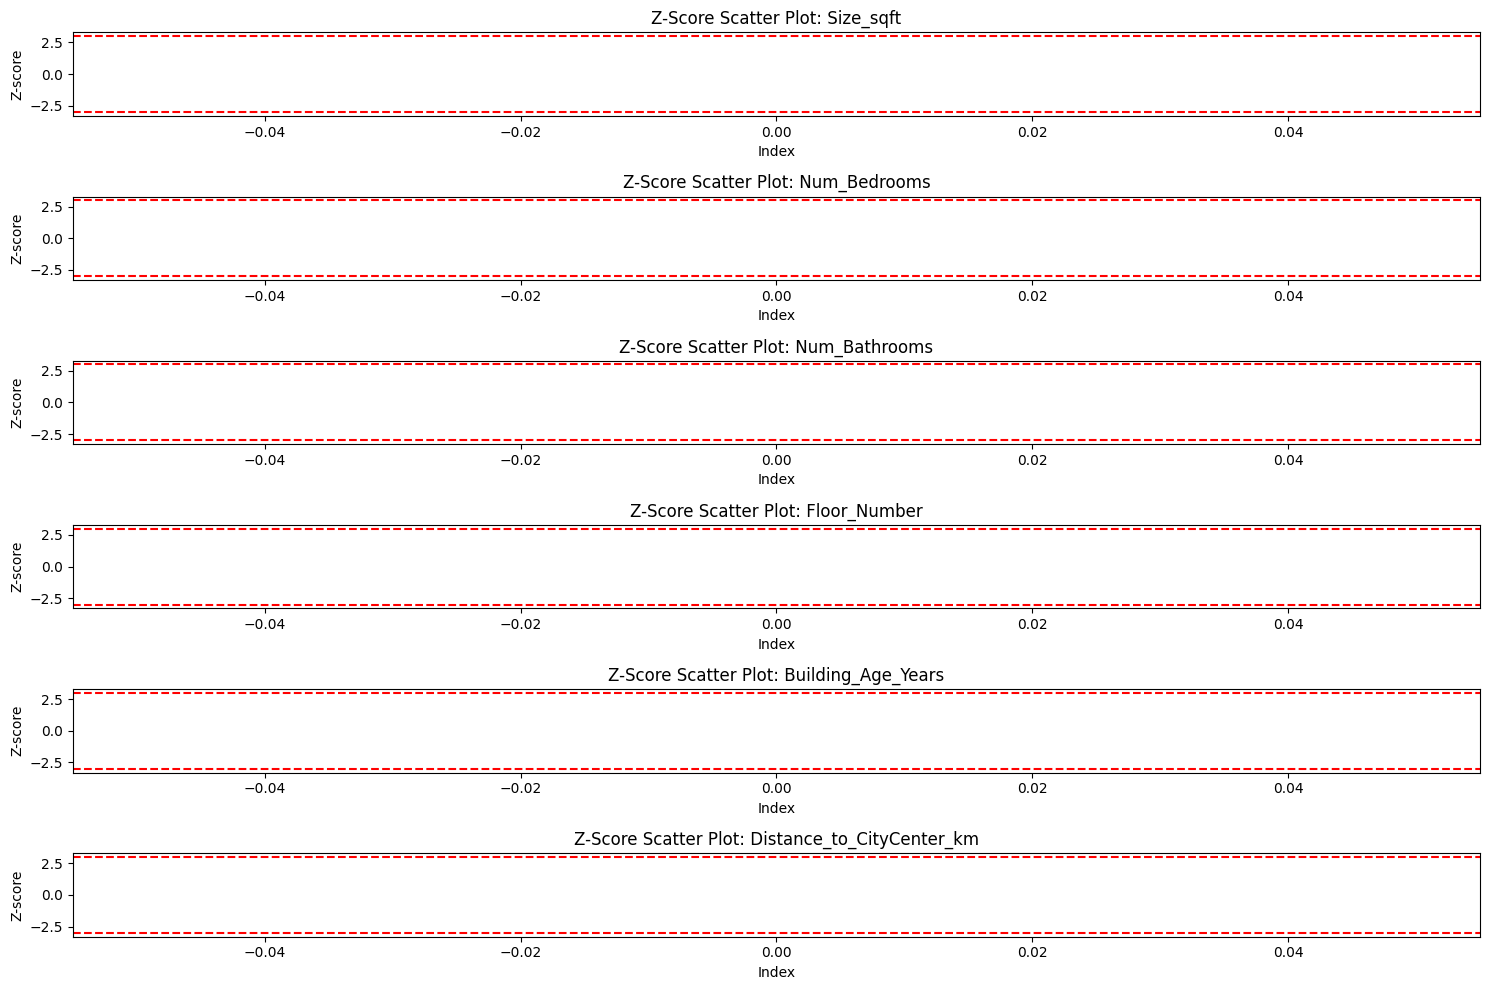

In [ ]:
#outliers checking
from scipy.stats import zscore

def detect_outliers_zscore(df, threshold=3.0):
    """Detect outliers using Z-score method, column-wise."""
    outlier_dict = {}
    for col in df.select_dtypes(include=np.number).columns:
        z_scores = np.abs(zscore(df[col]))
        outliers = df[z_scores > threshold]
        outlier_dict[col] = outliers.index.tolist()
    return outlier_dict


def summarize_outliers(outlier_dict):
    """Summarize number of outliers per column and show overlapping ones."""
    summary = {col: len(idxs) for col, idxs in outlier_dict.items()}
    all_indices = sum(outlier_dict.values(), [])
    overall_outliers = set(all_indices)
    return pd.DataFrame.from_dict(summary, orient='index', columns=['Num_Outliers']), overall_outliers

def plot_zscore_scatter(df, threshold=3.0):
    numeric_cols = df.select_dtypes(include='number').columns
    z_df = df[numeric_cols].apply(zscore)

    plt.figure(figsize=(15, 10))
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(len(numeric_cols), 1, i)
        plt.scatter(df.index, z_df[col], c=(abs(z_df[col]) > threshold), cmap='coolwarm', s=10)
        plt.axhline(y=threshold, color='r', linestyle='--')
        plt.axhline(y=-threshold, color='r', linestyle='--')
        plt.title(f'Z-Score Scatter Plot: {col}')
        plt.ylabel('Z-score')
        plt.xlabel('Index')
    plt.tight_layout()
    plt.show()
# Step 1: Use either method
zscore_outliers = detect_outliers_zscore(df)

# Step 2: Summarize
zscore_summary, zscore_indices = summarize_outliers(zscore_outliers)


print("Z-Score Outliers per Column:\n", zscore_summary)

# Plot Z-score scatter to highlight outlier points
plot_zscore_scatter(df)



Visualizing the distribution of numerical features.


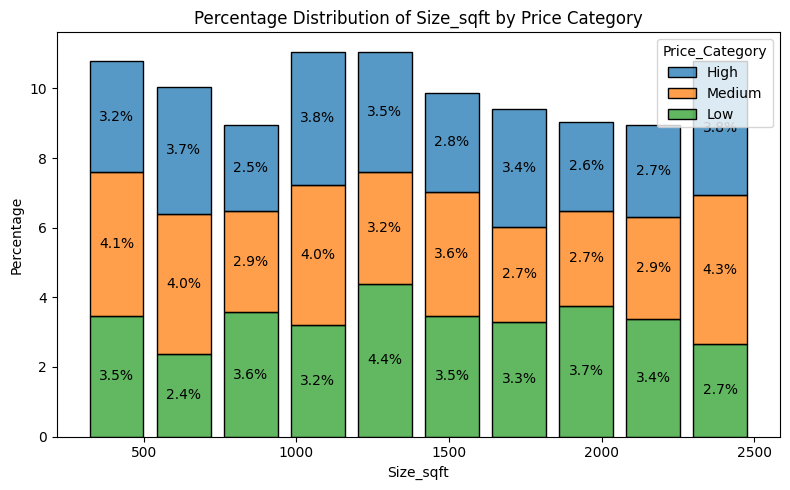

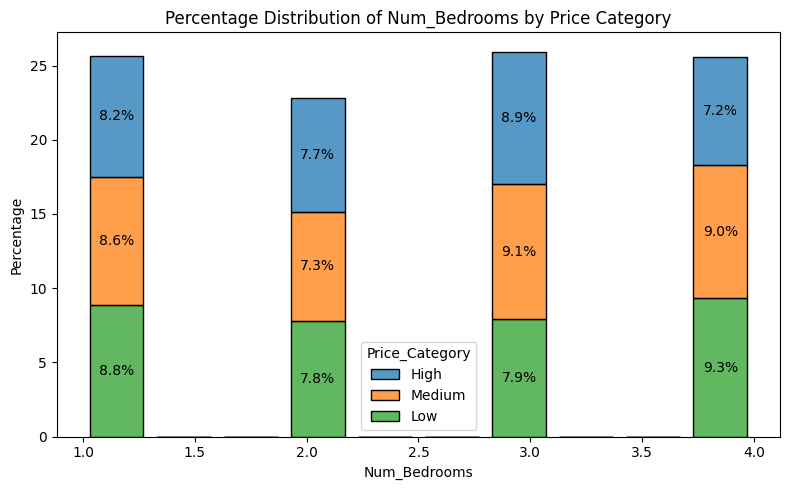

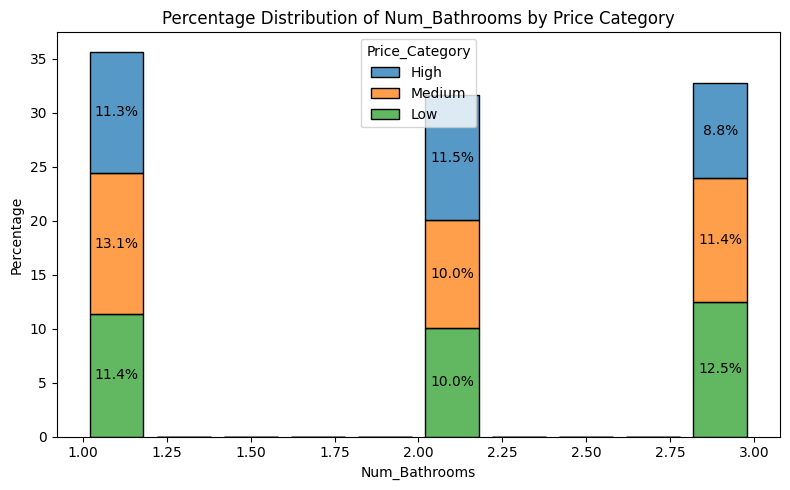

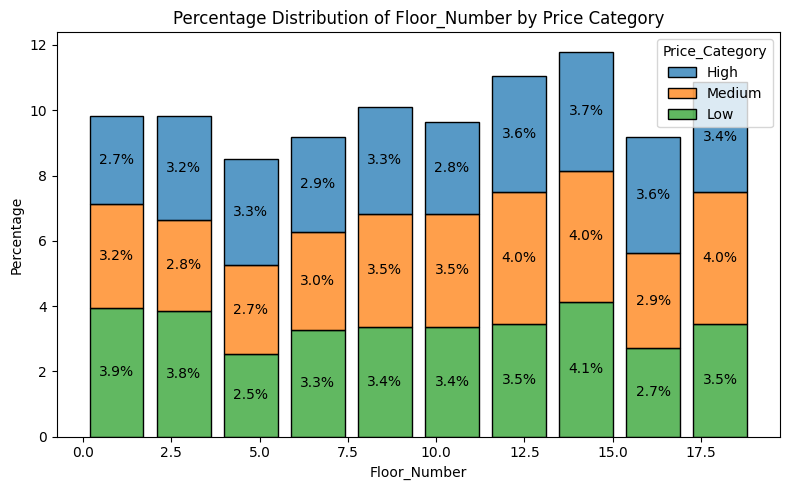

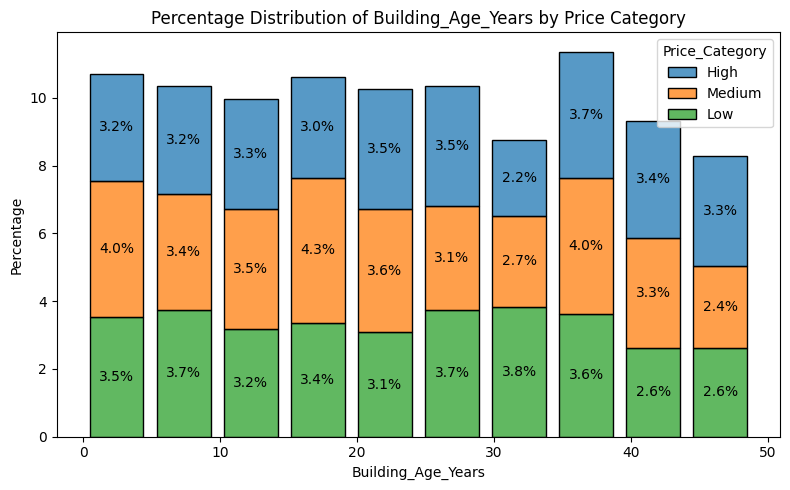

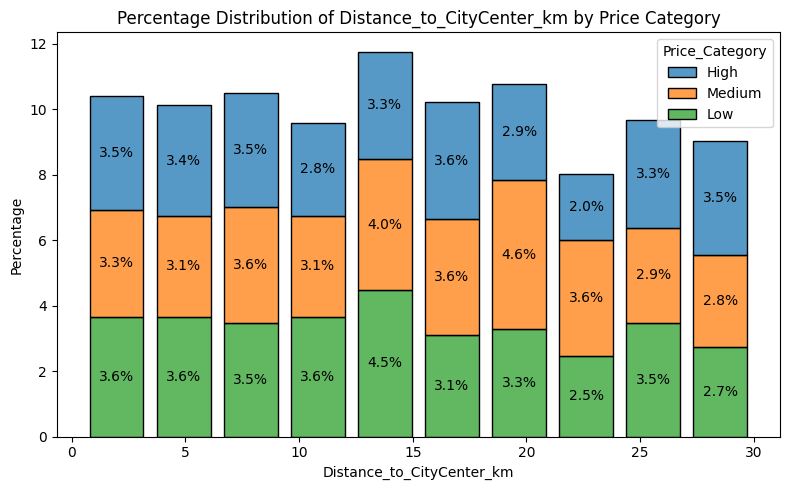

In [ ]:
for num_col in num_cols:
    plt.figure(figsize=(8, 5))

    # Create histogram and keep reference to the Axes
    ax = sns.histplot(
        data=df,
        x=num_col,
        hue='Price_Category',
        multiple='stack',
        stat='percent', bins=10,
        shrink=0.8
    )

    # Dictionary to track cumulative heights for each bar (by x position)
    cumulative_heights = {}

    for p in ax.patches:
        height = p.get_height()
        if height == 0:
            continue

        # Calculate x position (center of bar)
        x = p.get_x() + p.get_width() / 2.

        # Stack heights for each x position
        base = cumulative_heights.get(x, 0)
        cumulative_heights[x] = base + height

        # Annotate above the current segment
        ax.annotate(f'{height:.1f}%', (x, base + height / 2),
                    ha='center', va='center', fontsize=10, color='black')

    plt.title(f'Percentage Distribution of {num_col} by Price Category')
    plt.ylabel('Percentage')
    plt.xlabel(num_col)
    plt.tight_layout()
    plt.show()




Visualizing the distribution of categorical features.

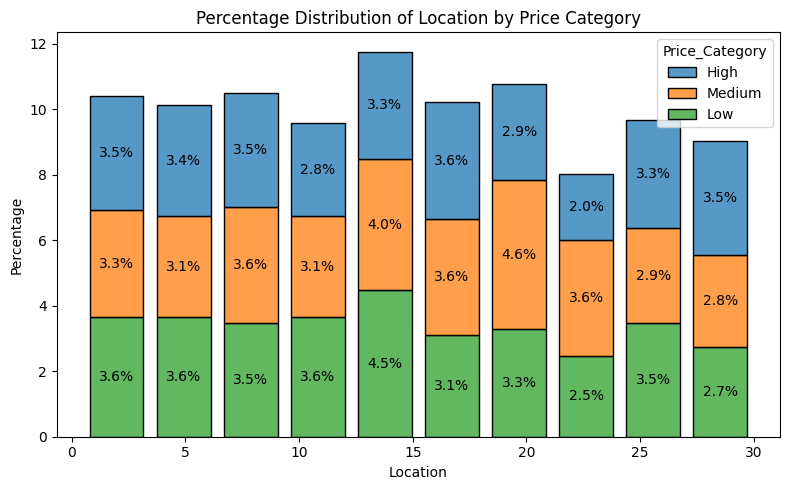

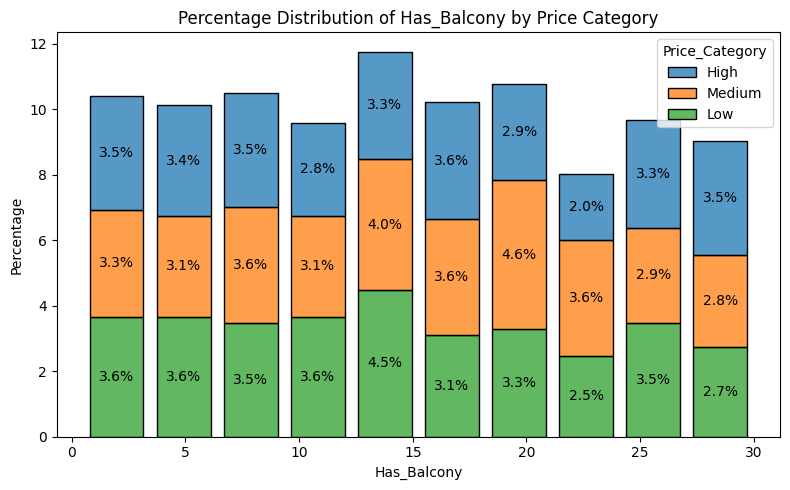

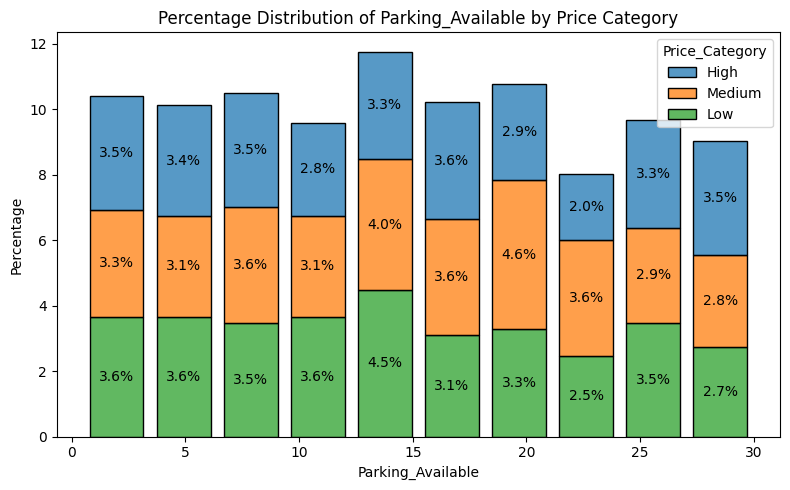

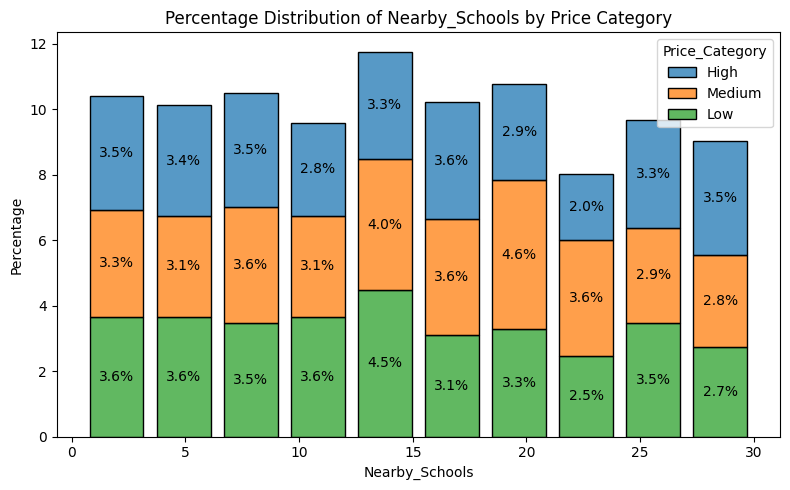

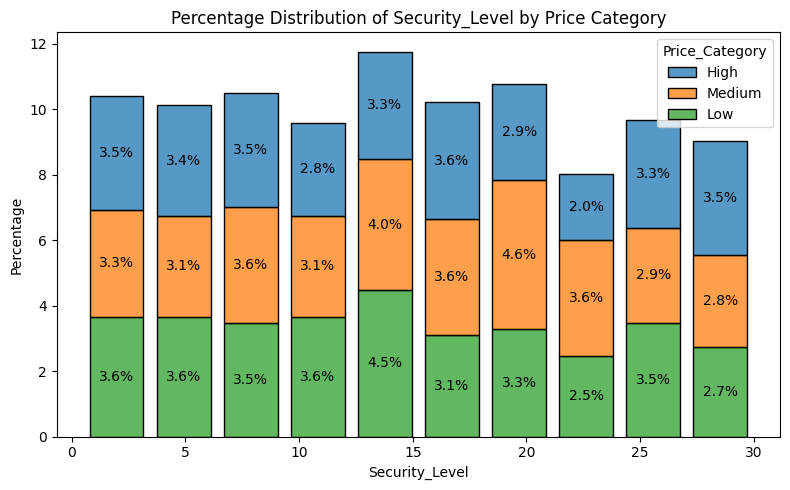

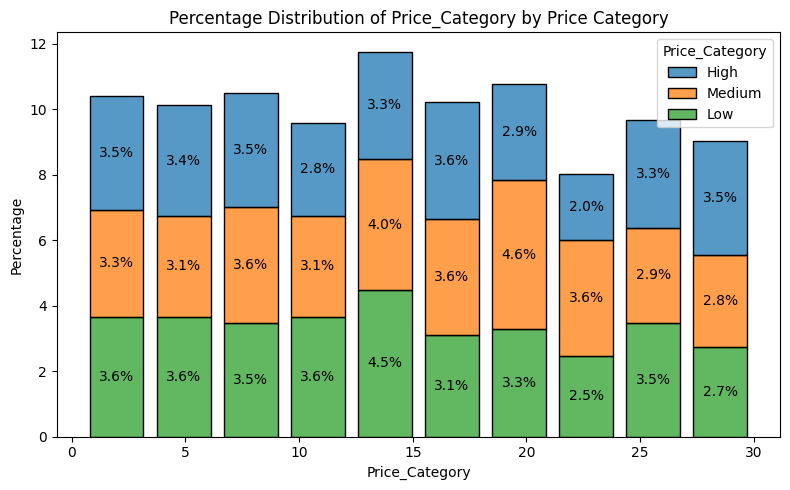

In [ ]:
for i in cat_cols:
    plt.figure(figsize=(8, 5))

    # Create histogram and keep reference to the Axes
    ax = sns.histplot(
        data=df,
        x=num_col,
        hue='Price_Category',
        multiple='stack',
        stat='percent', bins=10,
        shrink=0.8
    )

    # Dictionary to track cumulative heights for each bar (by x position)
    cumulative_heights = {}

    for p in ax.patches:
        height = p.get_height()
        if height == 0:
            continue

        # Calculate x position (center of bar)
        x = p.get_x() + p.get_width() / 2.

        # Stack heights for each x position
        base = cumulative_heights.get(x, 0)
        cumulative_heights[x] = base + height

        # Annotate above the current segment
        ax.annotate(f'{height:.1f}%', (x, base + height / 2),
                    ha='center', va='center', fontsize=10, color='black')

    plt.title(f'Percentage Distribution of {i} by Price Category')
    plt.ylabel('Percentage')
    plt.xlabel(i)
    plt.tight_layout()
    plt.show()

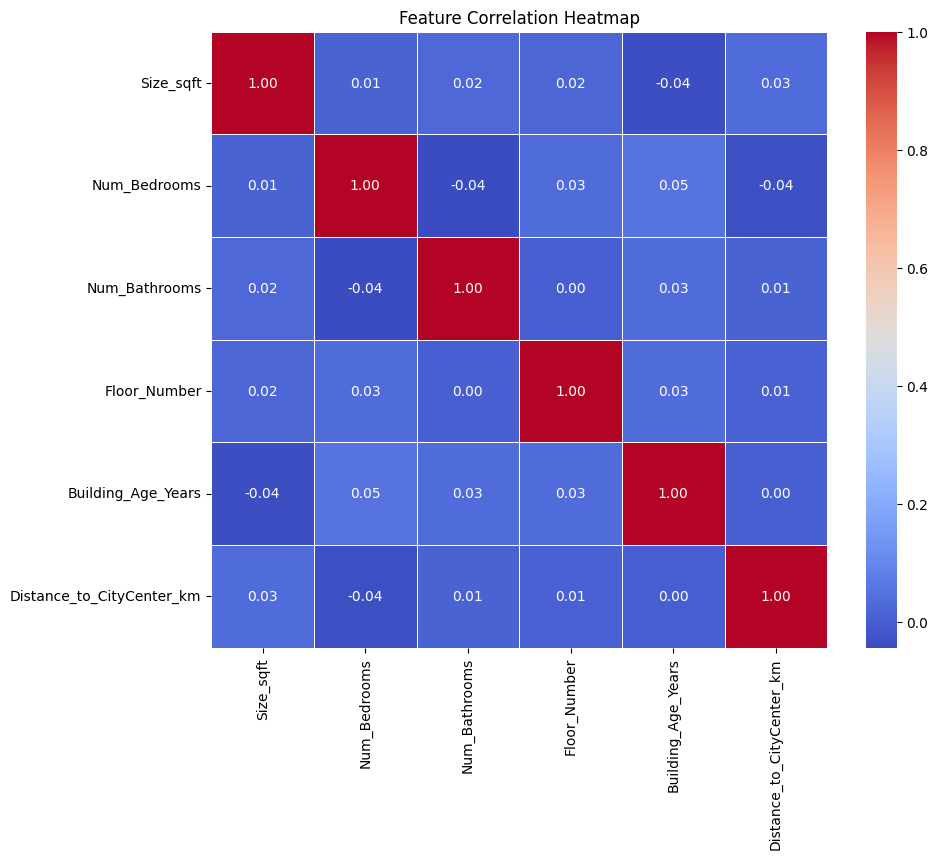

In [ ]:
# Compute correlation matrix (only numeric columns)
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

All the features have very low correlations with each other.

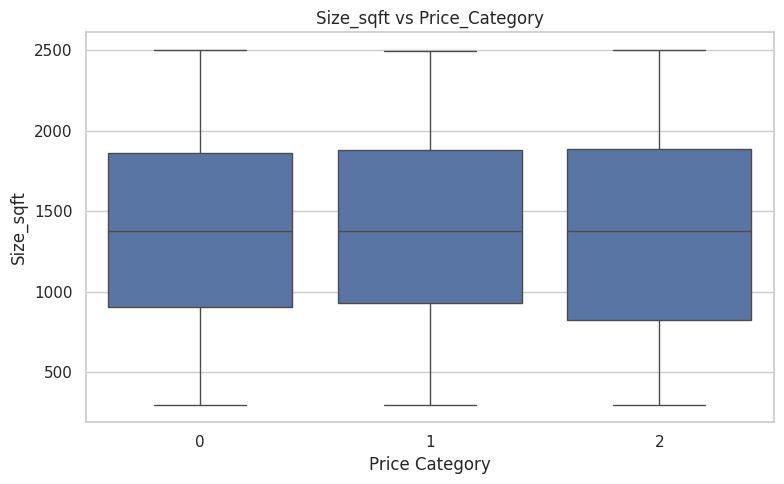

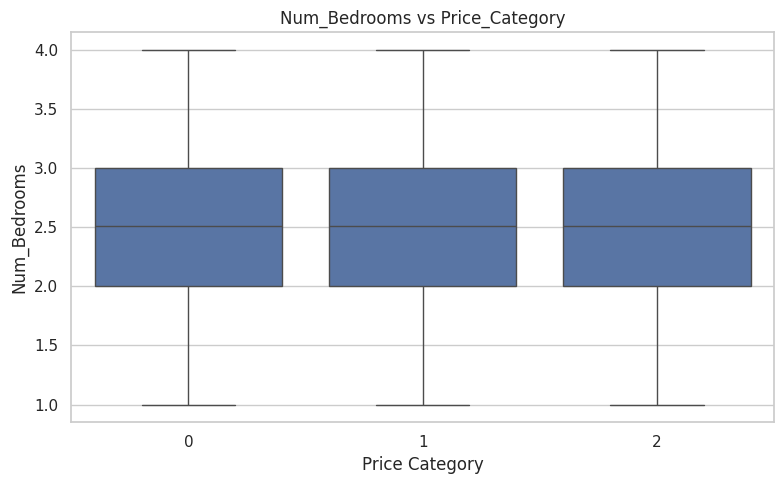

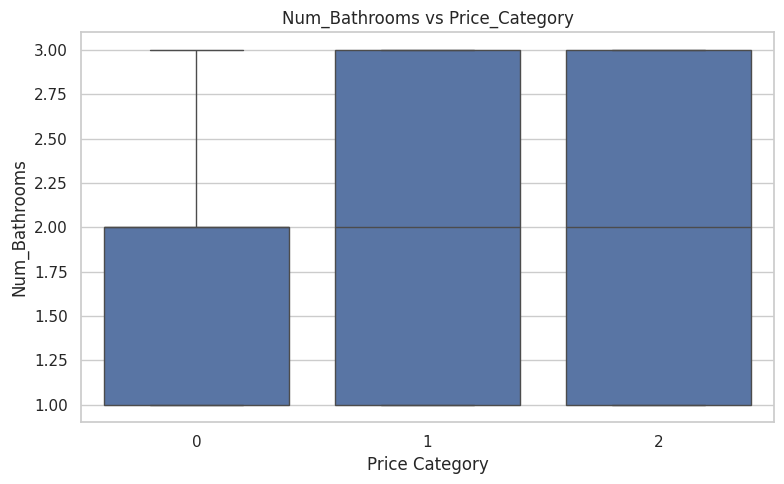

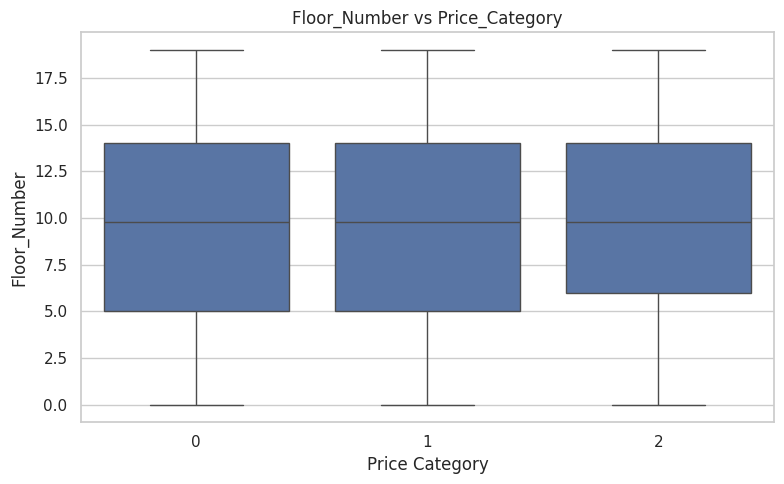

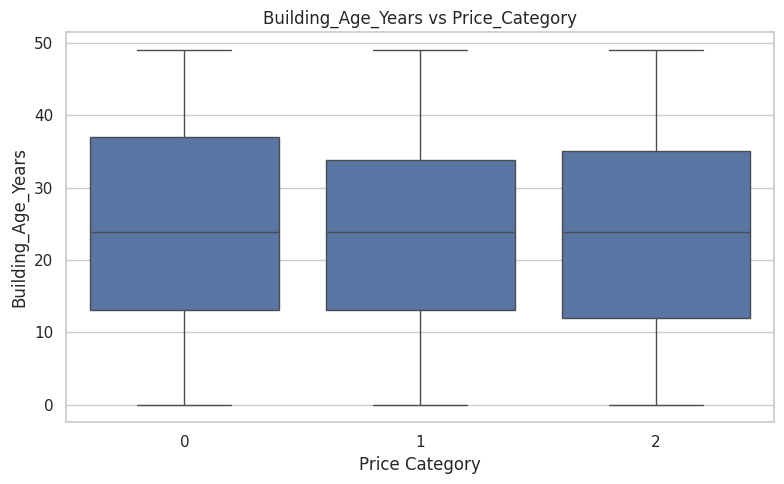

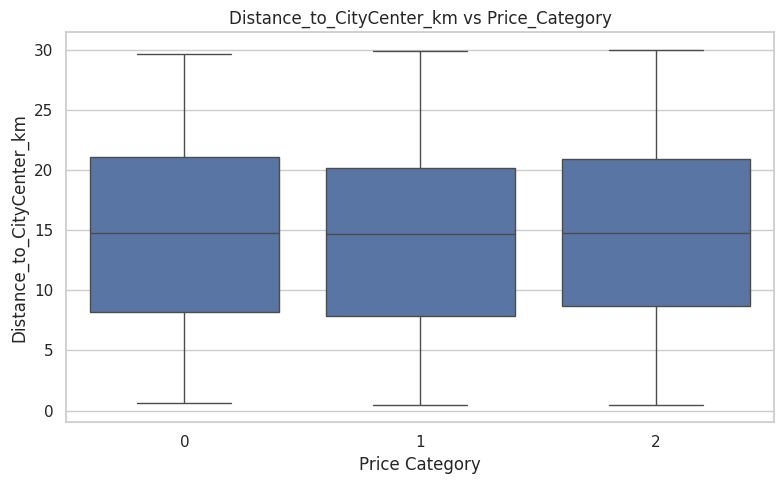

In [ ]:

# Remove target column from numerical columns if present
num_features = [col for col in num_cols if col != 'Price_Category']

# Plot boxplots of each numerical feature vs Price_Category
sns.set(style="whitegrid")

for feature in num_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Price_Category', y=feature, data=df)
    plt.title(f'{feature} vs Price_Category')
    plt.xlabel('Price Category')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

There is no strong separation between Price_Category and any other features. Bathroom count has a slight positive relationship with price category, but it is not strongly discriminative on its own.

In [ ]:
df['Price_Category'].value_counts()

,count
Price_Category,
2,413
1,402
0,385


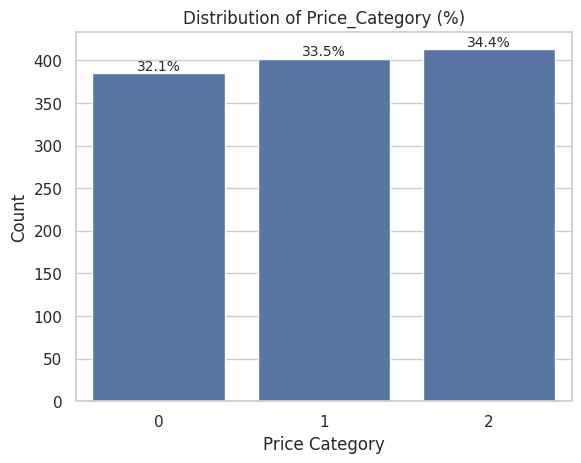

In [ ]:
# Count values and compute percentage
total = len(df)
ax = sns.countplot(x='Price_Category', data=df)

# Annotate each bar
for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('Distribution of Price_Category (%)')
plt.xlabel('Price Category')
plt.ylabel('Count')
plt.show()

The Dataset is Balanced.

# Feature Engineering


In [ ]:
#drop duplicates
df = df.drop_duplicates()
df.shape

(1200, 12)

Numerical Column handling

In [ ]:
columns_to_fill = ['Size_sqft','Num_Bedrooms','Floor_Number', 'Num_Bathrooms', 'Building_Age_Years', 'Distance_to_CityCenter_km']

# Fill these columns with their mean
for col in columns_to_fill:
    df[col] = df[col].fillna(df[col].mean())

df


,Location,Size_sqft,Num_Bedrooms,Num_Bathrooms,Has_Balcony,Floor_Number,Building_Age_Years,Parking_Available,Nearby_Schools,Distance_to_CityCenter_km,Security_Level,Price_Category
0,Countryside,1730.000000,4.0,3.000000,No,3.0,24.0,No,Few,19.200000,Low,High
1,City Center,2092.000000,1.0,2.000000,No,16.0,36.0,No,Many,2.600000,Low,High
2,Countryside,1379.874771,3.0,1.000000,Yes,8.0,47.0,No,Many,14.807475,Medium,Medium
3,NaN,1945.000000,3.0,2.000000,Yes,18.0,42.0,Yes,Few,28.800000,Low,High
4,City Center,1505.000000,4.0,3.000000,No,4.0,37.0,No,Many,2.800000,Low,High
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,Suburbs,2385.000000,1.0,3.000000,Yes,12.0,24.0,No,Many,24.100000,Low,High
1196,City Center,2095.000000,4.0,3.000000,Yes,14.0,8.0,Yes,Many,12.200000,High,High
1197,Suburbs,487.000000,4.0,1.970672,No,0.0,26.0,Yes,Few,10.400000,Low,Medium
1198,Countryside,1380.000000,2.0,3.000000,NaN,10.0,0.0,Yes,Many,7.400000,Medium,High


Categorical Columns handling

In [ ]:
# Imputing missing values in categorical columns using the mode (most frequent value)
categorical_columns = ['Location', 'Has_Balcony', 'Parking_Available', 'Nearby_Schools', 'Security_Level']

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)

df


,Location,Size_sqft,Num_Bedrooms,Num_Bathrooms,Has_Balcony,Floor_Number,Building_Age_Years,Parking_Available,Nearby_Schools,Distance_to_CityCenter_km,Security_Level,Price_Category
0,Countryside,1730.000000,4.0,3.000000,No,3.0,24.0,No,Few,19.200000,Low,High
1,City Center,2092.000000,1.0,2.000000,No,16.0,36.0,No,Many,2.600000,Low,High
2,Countryside,1379.874771,3.0,1.000000,Yes,8.0,47.0,No,Many,14.807475,Medium,Medium
3,City Center,1945.000000,3.0,2.000000,Yes,18.0,42.0,Yes,Few,28.800000,Low,High
4,City Center,1505.000000,4.0,3.000000,No,4.0,37.0,No,Many,2.800000,Low,High
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,Suburbs,2385.000000,1.0,3.000000,Yes,12.0,24.0,No,Many,24.100000,Low,High
1196,City Center,2095.000000,4.0,3.000000,Yes,14.0,8.0,Yes,Many,12.200000,High,High
1197,Suburbs,487.000000,4.0,1.970672,No,0.0,26.0,Yes,Few,10.400000,Low,Medium
1198,Countryside,1380.000000,2.0,3.000000,No,10.0,0.0,Yes,Many,7.400000,Medium,High


In [ ]:
df.isnull().sum()

,0
Location,0
Size_sqft,0
Num_Bedrooms,0
Num_Bathrooms,0
Has_Balcony,0
Floor_Number,0
Building_Age_Years,0
Parking_Available,0
Nearby_Schools,0
Distance_to_CityCenter_km,0


Encoding

In [ ]:
# Columns to encode
multi_class_columns = ['Location', 'Nearby_Schools', 'Security_Level', 'Price_Category']

# Label Encoding
le = LabelEncoder()
for col in multi_class_columns:
    df[col] = le.fit_transform(df[col])

df

,Location,Size_sqft,Num_Bedrooms,Num_Bathrooms,Has_Balcony,Floor_Number,Building_Age_Years,Parking_Available,Nearby_Schools,Distance_to_CityCenter_km,Security_Level,Price_Category
0,1,1730.000000,4.0,3.000000,No,3.0,24.0,No,0,19.200000,1,0
1,0,2092.000000,1.0,2.000000,No,16.0,36.0,No,1,2.600000,1,0
2,1,1379.874771,3.0,1.000000,Yes,8.0,47.0,No,1,14.807475,2,2
3,0,1945.000000,3.0,2.000000,Yes,18.0,42.0,Yes,0,28.800000,1,0
4,0,1505.000000,4.0,3.000000,No,4.0,37.0,No,1,2.800000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2,2385.000000,1.0,3.000000,Yes,12.0,24.0,No,1,24.100000,1,0
1196,0,2095.000000,4.0,3.000000,Yes,14.0,8.0,Yes,1,12.200000,0,0
1197,2,487.000000,4.0,1.970672,No,0.0,26.0,Yes,0,10.400000,1,2
1198,1,1380.000000,2.0,3.000000,No,10.0,0.0,Yes,1,7.400000,2,0


In [ ]:
# Binary Encoding for 'Has_Balcony' and 'Parking_Available'
binary_mapping = {'Yes': 1, 'No': 0}

df['Has_Balcony'] = df['Has_Balcony'].map(binary_mapping)
df['Parking_Available'] = df['Parking_Available'].map(binary_mapping)

df

,Location,Size_sqft,Num_Bedrooms,Num_Bathrooms,Has_Balcony,Floor_Number,Building_Age_Years,Parking_Available,Nearby_Schools,Distance_to_CityCenter_km,Security_Level,Price_Category
0,1,1730.000000,4.0,3.000000,0,3.0,24.0,0,0,19.200000,1,0
1,0,2092.000000,1.0,2.000000,0,16.0,36.0,0,1,2.600000,1,0
2,1,1379.874771,3.0,1.000000,1,8.0,47.0,0,1,14.807475,2,2
3,0,1945.000000,3.0,2.000000,1,18.0,42.0,1,0,28.800000,1,0
4,0,1505.000000,4.0,3.000000,0,4.0,37.0,0,1,2.800000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2,2385.000000,1.0,3.000000,1,12.0,24.0,0,1,24.100000,1,0
1196,0,2095.000000,4.0,3.000000,1,14.0,8.0,1,1,12.200000,0,0
1197,2,487.000000,4.0,1.970672,0,0.0,26.0,1,0,10.400000,1,2
1198,1,1380.000000,2.0,3.000000,0,10.0,0.0,1,1,7.400000,2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Location                   1200 non-null   int64  
 1   Size_sqft                  1200 non-null   float64
 2   Num_Bedrooms               1200 non-null   float64
 3   Num_Bathrooms              1200 non-null   float64
 4   Has_Balcony                1200 non-null   int64  
 5   Floor_Number               1200 non-null   float64
 6   Building_Age_Years         1200 non-null   float64
 7   Parking_Available          1200 non-null   int64  
 8   Nearby_Schools             1200 non-null   int64  
 9   Distance_to_CityCenter_km  1200 non-null   float64
 10  Security_Level             1200 non-null   int64  
 11  Price_Category             1200 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 112.6 KB


# Model Training

In [ ]:
#setting target column
X = df.drop(columns=["Price_Category"])
y = df["Price_Category"]

In [ ]:
# Dictionary to store results
results = {}
f1_scores = {}

# Function to evaluate models

def evaluate_model(y_true, y_pred, y_pred_proba=None):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro'),
        'Recall': recall_score(y_true, y_pred, average='macro'),
        'F1-Score': f1_score(y_true, y_pred, average='macro')
    }
    if y_pred_proba is not None:
        # For multiclass, need to set multi_class='ovr' (one-vs-rest) or 'ovo'
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr')
    return metrics


In [ ]:
# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

In [ ]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Decision Tree

--- Decision Tree ---
Accuracy: 0.3833
Precision: 0.3841
Recall: 0.3831
F1-Score: 0.3831
ROC-AUC: 0.5375




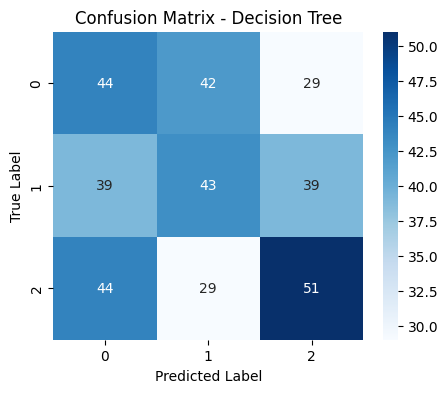

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
dt_preds = dt.predict(X_test_scaled)
dt_probs = dt.predict_proba(X_test_scaled)
results['Decision Tree'] = evaluate_model(y_test, dt_preds, dt_probs)
f1_scores['Decision Tree'] = results['Decision Tree']['F1-Score']
# Print the evaluation results for Decision Tree
print("--- Decision Tree ---")
for metric, value in results['Decision Tree'].items():
    print(f"{metric}: {value:.4f}")
print("\n")
plot_confusion_matrix(y_test, dt_preds, "Decision Tree")


KNN


--- KNN Classifier ---
Accuracy: 0.3167
Precision: 0.3152
Recall: 0.3196
F1-Score: 0.3068
ROC-AUC: 0.4684




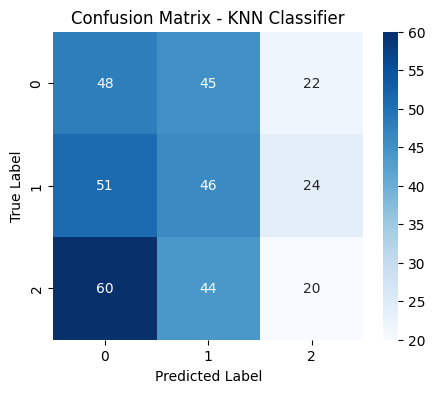

In [ ]:
# Initialize and Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # you can tune n_neighbors later
knn.fit(X_train_scaled, y_train)

# Predictions
knn_preds = knn.predict(X_test_scaled)
knn_probs = knn.predict_proba(X_test_scaled)

# Evaluate
results['KNN'] = evaluate_model(y_test, knn_preds, knn_probs)
f1_scores['KNN'] = results['KNN']['F1-Score']

# Print the evaluation results
print("--- KNN Classifier ---")
for metric, value in results['KNN'].items():
    print(f"{metric}: {value:.4f}")
print("\n")

# Plot Confusion Matrix
plot_confusion_matrix(y_test, knn_preds, "KNN Classifier")

Gaussian Naive Bayes

--- Gaussian Naive Bayes ---
Accuracy: 0.3500
Precision: 0.3453
Recall: 0.3478
F1-Score: 0.3452
ROC-AUC: 0.4957




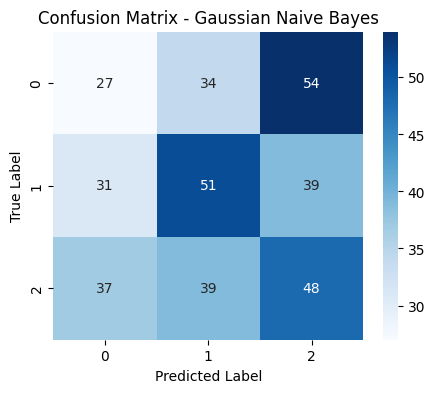

In [ ]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
gnb_preds = gnb.predict(X_test_scaled)
gnb_probs = gnb.predict_proba(X_test_scaled)
results['Gaussian Naive Bayes'] = evaluate_model(y_test, gnb_preds, gnb_probs)
f1_scores['Gaussian Naive Bayes'] = results['Gaussian Naive Bayes']['F1-Score']
# Print the evaluation results for Gaussian Naive Bayes
print("--- Gaussian Naive Bayes ---")
for metric, value in results['Gaussian Naive Bayes'].items():
    print(f"{metric}: {value:.4f}")
print("\n")
plot_confusion_matrix(y_test, gnb_preds, "Gaussian Naive Bayes")


Random Forest

--- Random Forest ---
Accuracy: 0.3444
Precision: 0.3442
Recall: 0.3436
F1-Score: 0.3439
ROC-AUC: 0.5019




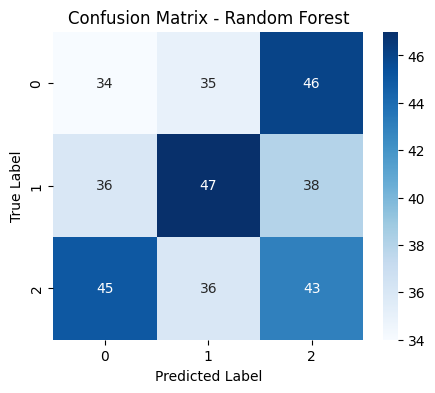

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)
rf_probs = rf.predict_proba(X_test_scaled)
results['Random Forest'] = evaluate_model(y_test, rf_preds, rf_probs)
f1_scores['Random Forest'] = results['Random Forest']['F1-Score']
# Print the evaluation results for Random Forest
print("--- Random Forest ---")
for metric, value in results['Random Forest'].items():
    print(f"{metric}: {value:.4f}")
print("\n")
plot_confusion_matrix(y_test, rf_preds, "Random Forest")


XGBoost

--- XGBoost ---
Accuracy: 0.3611
Precision: 0.3597
Recall: 0.3600
F1-Score: 0.3598
ROC-AUC: 0.5209




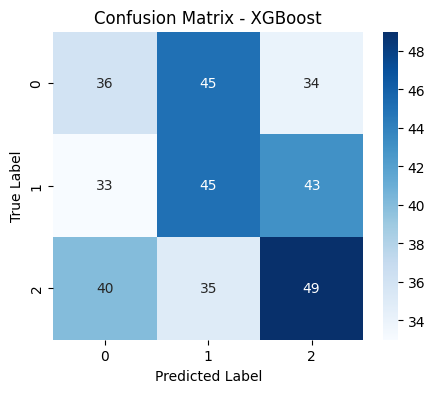

In [ ]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)
xgb_probs = xgb_model.predict_proba(X_test_scaled)
results['XGBoost'] = evaluate_model(y_test, xgb_preds, xgb_probs)
f1_scores['XGBoost'] = results['XGBoost']['F1-Score']
# Print the evaluation results for XGBoost
print("--- XGBoost ---")
for metric, value in results['XGBoost'].items():
    print(f"{metric}: {value:.4f}")
print("\n")
plot_confusion_matrix(y_test, xgb_preds, "XGBoost")

In [ ]:
# Create a DataFrame for better visualization of the evaluation metrics
metrics_df = pd.DataFrame(results).T

# Find the row corresponding to the highest F1-Score
best_model = max(f1_scores, key=f1_scores.get)

# Apply styling to the DataFrame for better readability
styled_metrics_df = (
    metrics_df.style
    .background_gradient(cmap='Blues', axis=None)
    .format('{:.4f}')
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#4c72b0'), ('color', 'white'), ('font-size', '14px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('font-size', '12px')]},
        {'selector': 'table', 'props': [('width', '100%'), ('border-collapse', 'collapse')]}
    ])
    .apply(lambda x: ['background-color: lightgreen' if x.name == best_model else '' for _ in x], axis=1)
)

# Display the styled DataFrame
styled_metrics_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Decision Tree,0.3833,0.3841,0.3831,0.3831,0.5375
KNN,0.3167,0.3152,0.3196,0.3068,0.4684
Gaussian Naive Bayes,0.3500,0.3453,0.3478,0.3452,0.4957
Random Forest,0.3444,0.3442,0.3436,0.3439,0.5019
XGBoost,0.3611,0.3597,0.3600,0.3598,0.5209


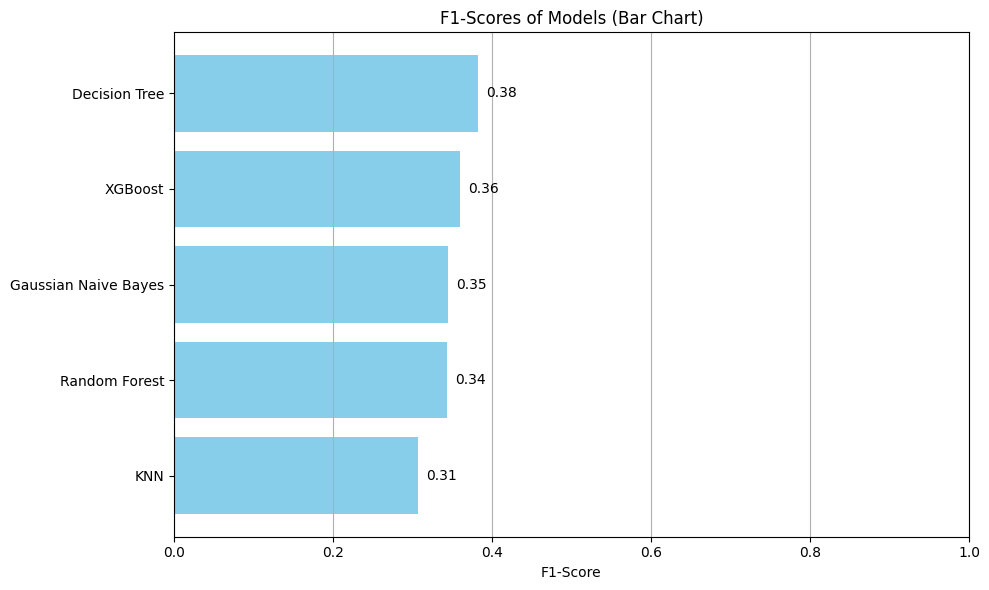

In [ ]:


# Sort F1-scores by value (optional)
sorted_f1 = dict(sorted(f1_scores.items(), key=lambda item: item[1]))

# Extract model names and scores
models = list(sorted_f1.keys())
scores = list(sorted_f1.values())

# Plot
plt.figure(figsize=(10, 6))
plt.barh(models, scores, color='skyblue')
for i, score in enumerate(scores):
    plt.text(score + 0.01, i, f"{score:.2f}", va='center')

plt.xlabel('F1-Score')
plt.title('F1-Scores of Models (Bar Chart)')
plt.xlim(0, 1)
plt.grid(axis='x')
plt.tight_layout()
plt.show()


Neural Network

In [ ]:
from tensorflow.keras.datasets import boston_housing
from tensorflow.keras.datasets import mnist
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [ ]:
from tensorflow.keras.layers import Dropout

model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
#early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_test, y_test))

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3535 - loss: 132.5802 - val_accuracy: 0.3417 - val_loss: 19.1965
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3330 - loss: 89.3959 - val_accuracy: 0.3667 - val_loss: 7.5799
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3186 - loss: 57.6964 - val_accuracy: 0.3194 - val_loss: 9.9504
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3314 - loss: 41.8342 - val_accuracy: 0.3194 - val_loss: 2.1169
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3601 - loss: 22.3211 - val_accuracy: 0.3250 - val_loss: 1.1790
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3534 - loss: 16.4437 - val_accuracy: 0.3444 - val_loss: 1.0987
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3131 - loss: 11.7618 - val_accuracy: 0.3444 - val_loss: 1.0987
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3256 - loss: 10.5679 - val_accuracy:

In [ ]:
def plot_confusion_matrix_heatmap_percent(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=False)

    plt.title(f'Confusion Matrix (%) for {model_name}', fontsize=16)
    plt.xlabel('Predicted Labels', fontsize=14)
    plt.ylabel('True Labels', fontsize=14)
    plt.show()


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


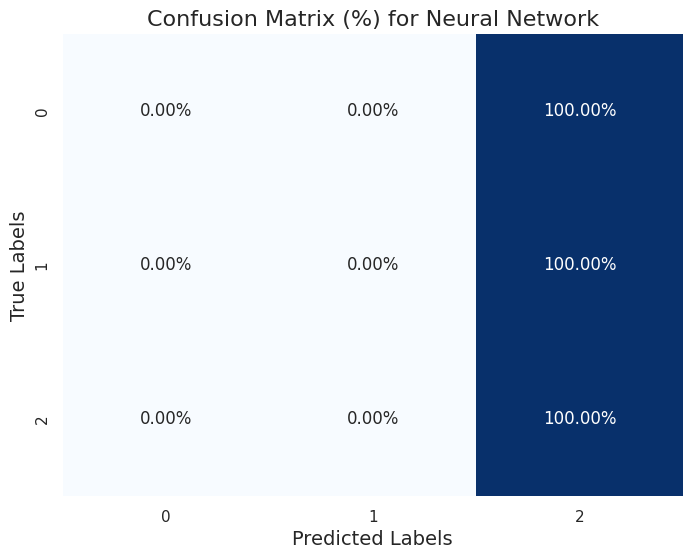

In [ ]:
nn_preds = model.predict(X_test)
nn_preds_labels = np.argmax(nn_preds, axis=1)

# Plot
plot_confusion_matrix_heatmap_percent(y_test, nn_preds_labels, "Neural Network")

# Or if you want percentage:
# plot_confusion_matrix_heatmap_percent(y_test, nn_preds_labels, "Neural Network")



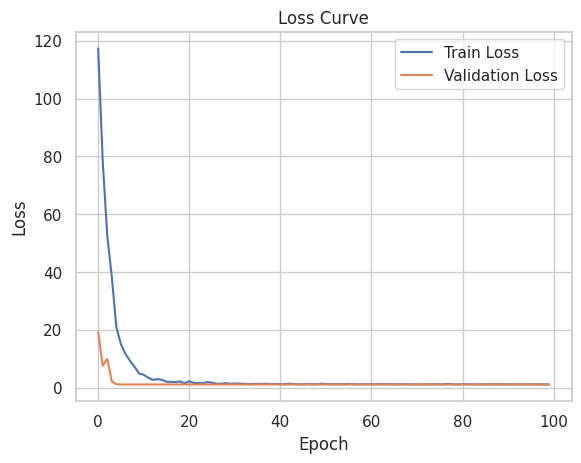

Testing Accuracy: 34.44%


In [ ]:
# Plot the Loss Curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -----------------------------
# Print Testing Accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Testing Accuracy: {round(test_accuracy * 100, 2)}%")